In [ ]:
# retrieving functions from lindbladian.ipnyb
%run '/home/jovyan/NSERC 2026/[1] [lindbladian helper code] [may 19]/lindbladian.ipynb'
plt.style.use(['science', 'high-vis'])

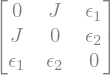

In [2]:
J = sp.Symbol("J", real=True, positive=True)
Jz = sp.Symbol("J_z", real=True, positive=True)
epsilon = sp.Symbol("epsilon", real=True, positive=True)
epsilon1, epsilon2 = sp.symbols("epsilon1 epsilon2", real=True, positive=True)
epsilon1z, epsilon2z = sp.symbols("epsilon_1z epsilon_2z", real=True, positive=True)
gamma = sp.Symbol("Gamma", real=True, positive=True)
delta = sp.Symbol("delta", real=True, positive=True)

N = 3 # number of sites
manifold = [3,5,6] # the rows/columns of the generic jump operators which correspond to our desired manifold

# building hamiltonian (ONLY flip-floping)
H_flipflop = sp.Matrix([[0, J, epsilon1],[J, 0, epsilon2],[epsilon1, epsilon2, 0]])
H_flipflop

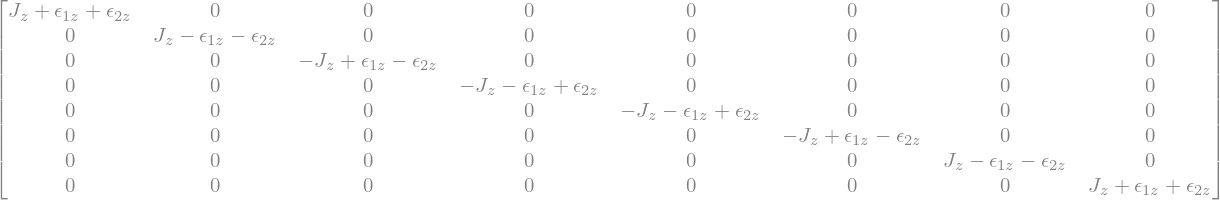

In [3]:
# building Hz in full manifold <-- accounts for spin-spin coupling/interactions
Hz_full = Jz*sigma(sigma_z, 0, N)*sigma(sigma_z, 1, N) + epsilon1z*sigma(sigma_z, 0, N)*sigma(sigma_z, 2, N) + epsilon2z*sigma(sigma_z, 1, N)*sigma(sigma_z, 2, N)

Hz_full

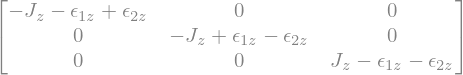

In [4]:
# projecting HZ_full onto two-excitation manifold
Hz = sp.Matrix(N, N, lambda i, j: Hz_full[manifold[i], manifold[j]])

Hz

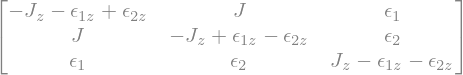

In [5]:
# building the complete hamiltonian
H = H_flipflop + Hz

H

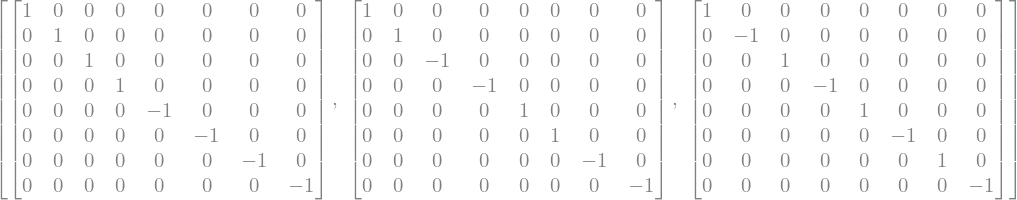

In [6]:
# returns jump operators in full 8-dimensional manifold
L_operators_full = [sigma(sigma_z, i, N) for i in range(N)]

L_operators_full

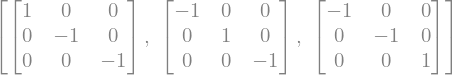

In [7]:
# projecting the jump operators onto the two-excitation manifold
L_operators_proj = [sp.Matrix(N, N, lambda i, j: operator[manifold[i], manifold[j]]) for operator in L_operators_full]
L_operators_proj

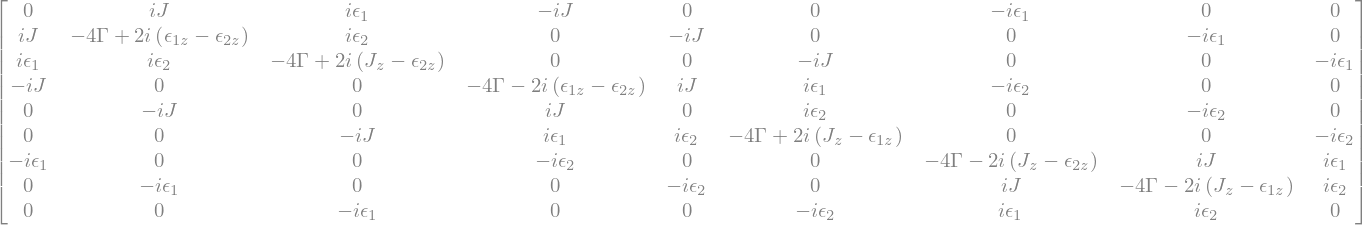

In [8]:
# constructing lindbladian
L, rho = lindbladian(N, output=False, degenerate=True, H=H, L_operators=L_operators_proj)
L = L.subs({sp.Symbol(f"Gamma_{i}", real=True, nonnegative=True): gamma for i in range(N)}).applyfunc(sp.simplify)

L

In [9]:
mathematica_code(L).replace("epsilon_1z", "θ").replace("epsilon_2z", "β").replace("Gamma","Γ").replace("epsilon1", "ϵ").replace("epsilon2", "α").replace("J_z", "τ")

'{{0, I*J, I*ϵ, -I*J, 0, 0, -I*ϵ, 0, 0}, {I*J, -4*Γ + 2*I*(θ - β), I*α, 0, -I*J, 0, 0, -I*ϵ, 0}, {I*ϵ, I*α, -4*Γ + 2*I*(τ - β), 0, 0, -I*J, 0, 0, -I*ϵ}, {-I*J, 0, 0, -4*Γ - 2*I*(θ - β), I*J, I*ϵ, -I*α, 0, 0}, {0, -I*J, 0, I*J, 0, I*α, 0, -I*α, 0}, {0, 0, -I*J, I*ϵ, I*α, -4*Γ + 2*I*(τ - θ), 0, 0, -I*α}, {-I*ϵ, 0, 0, -I*α, 0, 0, -4*Γ - 2*I*(τ - β), I*J, I*ϵ}, {0, -I*ϵ, 0, 0, -I*α, 0, I*J, -4*Γ - 2*I*(τ - θ), I*α}, {0, 0, -I*ϵ, 0, 0, -I*α, I*ϵ, I*α, 0}}'

In [10]:
evals_string = '''
(-12*\[CapitalGamma]*(J^2*(\[Alpha]^2 + \[Epsilon]^2) + 8*J*\[Alpha]*\[Epsilon]*\[Tau] + 4*(\[Alpha]^2 + \[Epsilon]^2)*(4*\[CapitalGamma]^2 + \[Tau]^2)))/(J^4 + 8*J^2*(4*\[CapitalGamma]^2 - \[Tau]^2) + 16*(4*\[CapitalGamma]^2 + \[Tau]^2)^2)
'''

<>:2: SyntaxWarning: invalid escape sequence '\['
<>:2: SyntaxWarning: invalid escape sequence '\['
/tmp/ipykernel_123/3510971636.py:2: SyntaxWarning: invalid escape sequence '\['
  (-12*\[CapitalGamma]*(J^2*(\[Alpha]^2 + \[Epsilon]^2) + 8*J*\[Alpha]*\[Epsilon]*\[Tau] + 4*(\[Alpha]^2 + \[Epsilon]^2)*(4*\[CapitalGamma]^2 + \[Tau]^2)))/(J^4 + 8*J^2*(4*\[CapitalGamma]^2 - \[Tau]^2) + 16*(4*\[CapitalGamma]^2 + \[Tau]^2)^2)


# eigenvalues approximated to $O(\epsilon_i^3)$

In [ ]:
evals_approx = [parse_mathematica(evals_string.replace(r"\[CapitalGamma]", "Gamma").replace(r"\[Epsilon]", "epsilon1").replace(r"\[Alpha]", "epsilon2").replace(r"\[Theta]", "epsilon3").replace(r"\[Beta]", "epsilon4").replace(r"\[Tau]", "Jz"))]

evals_approx = [i.subs({sp.Symbol("Gamma"): gamma, sp.Symbol("epsilon1"): epsilon1, sp.Symbol("epsilon2"): epsilon2, sp.Symbol("J"): J, sp.Symbol("epsilon3"): epsilon1z, sp.Symbol("epsilon4"): epsilon2z, sp.Symbol("Jz"):Jz}) for i in evals_approx]


for i in evals_approx:
    #display(sp.re(i.subs({gamma:1, J : 20, epsilon1:1, epsilon2:2})).evalf())
    display(i.simplify(deep=True))
    print("++++++++++++++++++++++++++++++")
    


expr = -6*gamma*((epsilon1-epsilon2)**2 / ((J+2*Jz)**2+16*gamma**2) + (epsilon1+epsilon2)**2 / ((J-2*Jz)**2+16*gamma**2))

display(expr)

display((expr-evals_approx[0]).simplify(deep=True))

evals_approx[0] = expr

# big $\Gamma$ limit

In [ ]:
# big gamma limit - second order in eta=1/gamma
evals_big_gamma = []
for i in evals_approx:
    i = i.subs(gamma, 1/sp.Symbol('eta')).series(sp.Symbol('eta'), 0, 3).subs({sp.Symbol('eta'): 1/gamma, epsilon1**2*epsilon2**2: 0}).removeO()
    evals_big_gamma.append(i)
    display(sp.Add((sp.re(i).factor()),sp.I*(sp.im(i)), evaluate=(True if sp.im(i)==0 else False)))
    

# small $\Gamma$ limit

In [ ]:
# small gamma limit - second order
evals_small_gamma = []
for i in evals_approx:
    i = i.series(gamma, 0, 3).subs(epsilon1**2*epsilon2**2, 0).removeO()
    evals_small_gamma.append(i)
    display(sp.Add((sp.re(i).simplify(deep=True)),sp.I*(sp.im(i)), evaluate=(True if sp.im(i)==0 else False)))

# case 1: set $\epsilon_1=\epsilon_2=\epsilon$

In [ ]:
# general
evals_approx[0].subs({epsilon1:epsilon, epsilon2: epsilon}).simplify(deep=True)

In [ ]:
# big gamma
evals_big_gamma[0].subs({epsilon1:epsilon, epsilon2: epsilon})

In [ ]:
# small gamma
evals_small_gamma[0].subs({epsilon1:epsilon, epsilon2: epsilon}).simplify(deep=True)

# case 2: set $\epsilon_1=0$ and $\epsilon_2=\epsilon$

In [ ]:
# general
evals_approx[0].subs({epsilon1:0, epsilon2: epsilon}).simplify(deep=True)

In [ ]:
# big gamma
evals_big_gamma[0].subs({epsilon1:0, epsilon2: epsilon})

In [ ]:
# small gamma
evals_small_gamma[0].subs({epsilon1:0, epsilon2: epsilon}).simplify(deep=True)

# case 3: set $\epsilon_1 = \epsilon + \delta$ and $\epsilon_2 = \epsilon - \delta$

In [ ]:
# general
evals_approx[0].subs({epsilon1:epsilon+delta, epsilon2:epsilon-delta}).simplify(deep=True)

In [ ]:
# big gamma
evals_big_gamma[0].subs({epsilon1:epsilon+delta, epsilon2:epsilon-delta}).expand().factor()

In [ ]:
# small gamma
evals_small_gamma[0].subs({epsilon1:epsilon+delta, epsilon2:epsilon-delta}).simplify(deep=True)

# time evolution

In [34]:
# time evolution
def rho_t(t, L, rho_0):
    return scipy.linalg.expm(np.array(L).astype(complex)*t)@rho_0

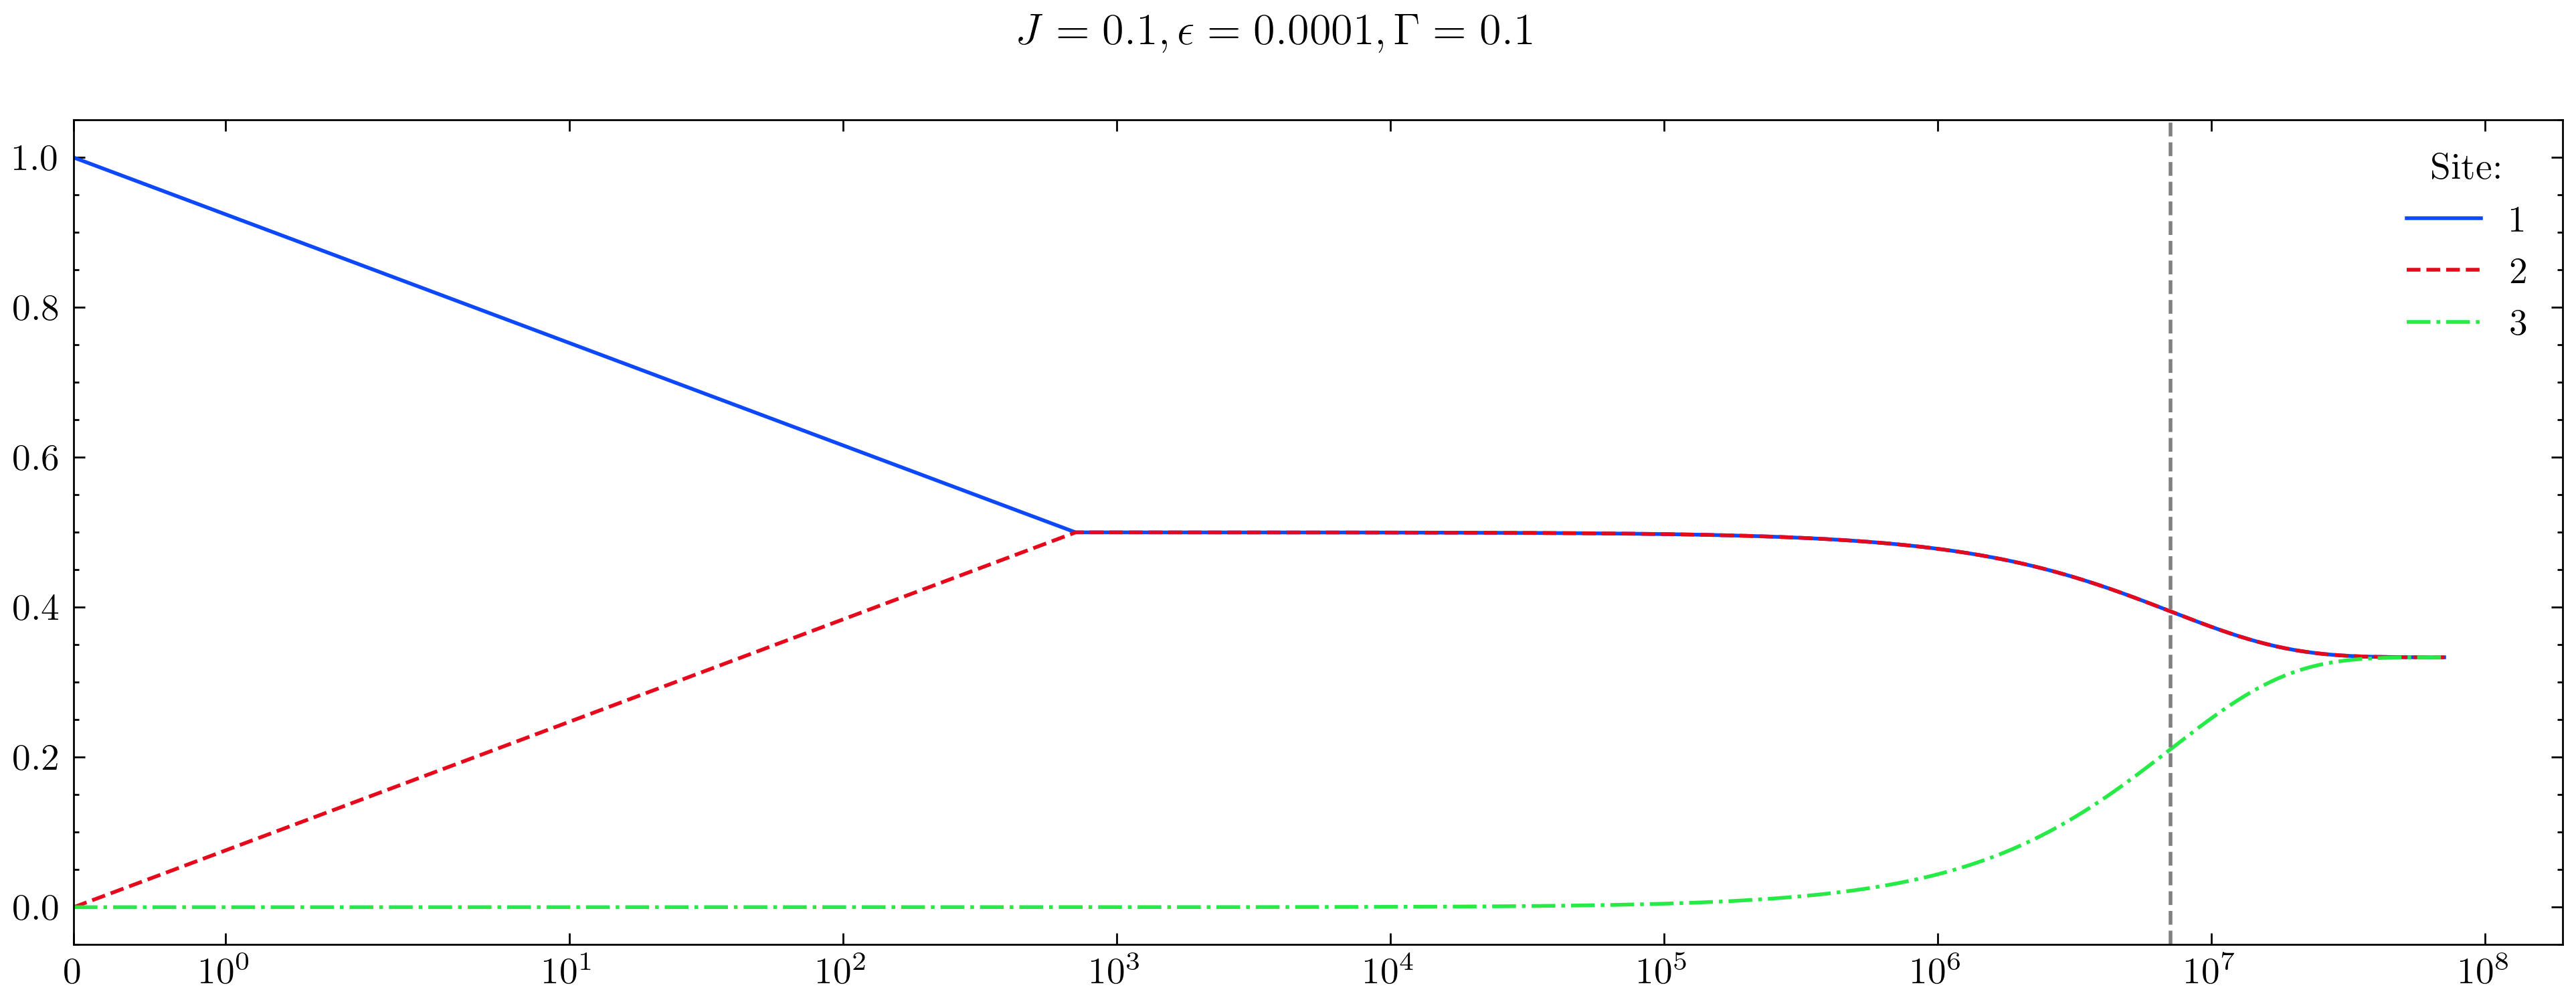

In [60]:
# constants
J_val = 1e-1
epsilon_val = 1e-4
gamma_val = 1e-1


# simulation parameters
time_start = 0
time_stop = (16*gamma_val**2 + J_val**2) / ( 24*gamma_val*epsilon_val**2 )
num_steps = 100000
times = np.linspace(time_start,time_stop*10**1, num_steps)

# initial conidition
rho_0 = np.array([1,0,0,0,0,0,0,0,0])


# subbing values into H
L_sub = L.subs({J:J_val, epsilon1:epsilon_val, epsilon2:epsilon_val, gamma:gamma_val, Jz:J_val, epsilon1z:epsilon_val, epsilon2z:epsilon_val})


# setting up fig
fig, axs = plt.subplots(1,1, figsize=(12,4))


# computing pops and cohs
rhos = np.asarray([rho_t(time, np.array(L_sub), rho_0) for time in times]).astype(complex)


# plotting
axs.plot(times, rhos[:,0], label="1")
axs.plot(times, rhos[:,4], label="2")
axs.plot(times, rhos[:,8], label="3")
axs.set_xscale('symlog') # setting log scale for x axis
axs.set_xlim(left=0)
axs.axvline(time_stop, ls="--", color='grey')
axs.legend(title="Site:")
#axs.set_title("Populations of all sites")


fig.suptitle(fr"$J={J_val}, \epsilon={epsilon_val}, \Gamma={gamma_val}$")

fig.savefig("initially in 1.pdf")
